# 03 - Modelagem e Predição

Etapas:
1. Carregar dados processados
2. Baseline com Cross-Validation (5 modelos)
3. Hyperparameter Tuning do melhor modelo
4. Predição final e geração de submission

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost não disponível - será pulado")

import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print("Bibliotecas importadas")

Bibliotecas importadas


## 1. Carregar Dados

In [47]:
# Carrega dados de treino
df_train = pd.read_csv("../data/processed/train_features.csv")
print(f"Train shape: {df_train.shape}")
print(f"Distribuição de classes:\n{df_train['label'].value_counts()}")

# Separa features e target
X_train = df_train.drop(columns=['nameseq', 'label'])
y_train = df_train['label']

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Amostras: {X_train.shape[0]}")

# Verifica missing values
print(f"\nMissing values: {X_train.isna().sum().sum()}")
print(f"Infinitos: {np.isinf(X_train.values).sum()}")

Train shape: (3880, 425)
Distribuição de classes:
label
1    1940
0    1940
Name: count, dtype: int64

Features: 423
Amostras: 3880

Missing values: 0
Infinitos: 0


In [48]:
# Carrega dados de teste
df_test = pd.read_csv("../data/processed/test_features.csv")
print(f"Test shape: {df_test.shape}")

X_test = df_test.drop(columns=['nameseq'])
test_ids = df_test['nameseq']

print(f"Test features: {X_test.shape[1]}")
print(f"Test Amostras: {X_test.shape[0]}")

Test shape: (970, 424)
Test features: 423
Test Amostras: 970


## 2. Baseline - Cross-Validation

In [ ]:
# === BASELINE: Teste de múltiplos modelos com CV ===

# Configuração do Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário de modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=100, 
        random_state=42, 
        eval_metric='logloss',
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100, 
        random_state=42, 
        verbose=-1,
        n_jobs=-1, 
        force_col_wise=True
    ),
    'SVM': SVC(probability=True, random_state=42),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
}

# Adiciona CatBoost se disponível
if CATBOOST_AVAILABLE:
    models['CatBoost'] = CatBoostClassifier(
        iterations=100,
        random_state=42,
        verbose=0
    )

# Armazena resultados
results = []

print("Treinando modelos com 5-Fold Cross-Validation...\n")

for name, model in models.items():
    print(f"Treinando {name}...")
    
    # Cross-validation com múltiplas métricas
    scores_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    scores_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    scores_roc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    
    results.append({
        'Modelo': name,
        'Accuracy': scores_acc.mean(),
        'Accuracy_std': scores_acc.std(),
        'F1-Score': scores_f1.mean(),
        'F1_std': scores_f1.std(),
        'ROC-AUC': scores_roc.mean(),
        'ROC_std': scores_roc.std()
    })
    
    print(f"Accuracy: {scores_acc.mean():.4f} (±{scores_acc.std():.4f})")
    print(f"F1-Score: {scores_f1.mean():.4f} (±{scores_f1.std():.4f})")
    print(f"ROC-AUC:  {scores_roc.mean():.4f} (±{scores_roc.std():.4f})\n")

Treinando modelos com 5-Fold Cross-Validation...

Treinando Logistic Regression...
Accuracy: 0.7778 (±0.0117)
F1-Score: 0.7769 (±0.0130)
ROC-AUC:  0.8603 (±0.0129)

Treinando Random Forest...
Accuracy: 0.7778 (±0.0117)
F1-Score: 0.7769 (±0.0130)
ROC-AUC:  0.8603 (±0.0129)

Treinando Random Forest...
Accuracy: 0.8472 (±0.0101)
F1-Score: 0.8433 (±0.0113)
ROC-AUC:  0.9323 (±0.0074)

Treinando XGBoost...
Accuracy: 0.8472 (±0.0101)
F1-Score: 0.8433 (±0.0113)
ROC-AUC:  0.9323 (±0.0074)

Treinando XGBoost...
Accuracy: 0.8508 (±0.0127)
F1-Score: 0.8489 (±0.0144)
ROC-AUC:  0.9308 (±0.0063)

Treinando LightGBM...
Accuracy: 0.8508 (±0.0127)
F1-Score: 0.8489 (±0.0144)
ROC-AUC:  0.9308 (±0.0063)

Treinando LightGBM...
Accuracy: 0.8534 (±0.0115)
F1-Score: 0.8518 (±0.0119)
ROC-AUC:  0.9341 (±0.0061)

Treinando SVM...
Accuracy: 0.8534 (±0.0115)
F1-Score: 0.8518 (±0.0119)
ROC-AUC:  0.9341 (±0.0061)

Treinando SVM...


KeyboardInterrupt: 

In [45]:
# Resultados em tabela
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('ROC-AUC', ascending=False)
print("Resultados do Baseline (ordenado por ROC-AUC):\n")
print(df_results.to_string(index=False))

Resultados do Baseline (ordenado por ROC-AUC):

             Modelo  Accuracy  Accuracy_std  F1-Score   F1_std  ROC-AUC  ROC_std
           LightGBM  0.853351      0.011509  0.851822 0.011902 0.934055 0.006070
      Random Forest  0.847165      0.010068  0.843329 0.011255 0.932294 0.007421
            XGBoost  0.850773      0.012715  0.848944 0.014400 0.930848 0.006280
Logistic Regression  0.777835      0.011686  0.776948 0.012961 0.860295 0.012886


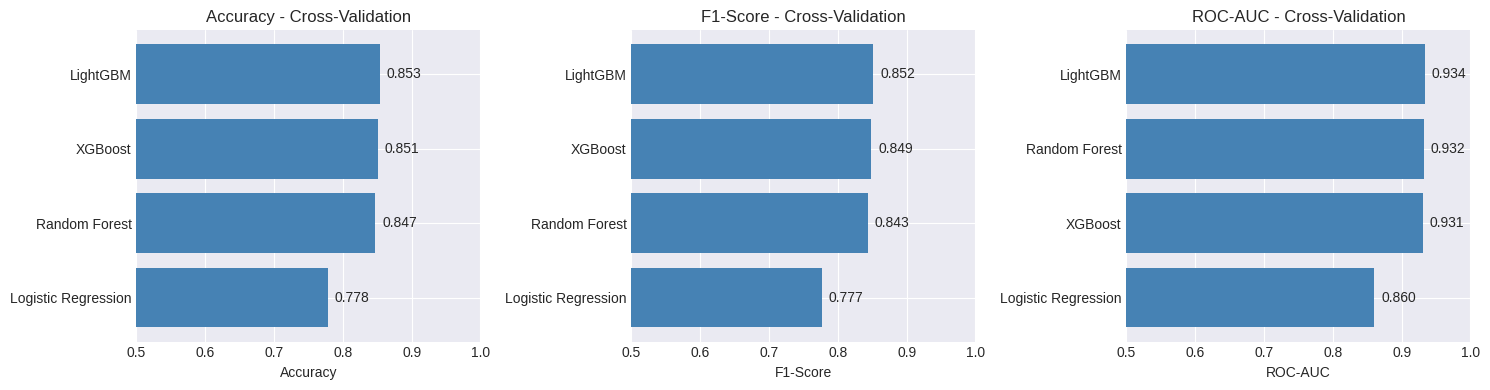


Melhor modelo (por ROC-AUC): LightGBM


In [46]:
# Visualização
import os
os.makedirs('../data/processed', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, metric in enumerate(['Accuracy', 'F1-Score', 'ROC-AUC']):
    ax = axes[idx]
    df_plot = df_results.sort_values(metric, ascending=True)
    ax.barh(df_plot['Modelo'], df_plot[metric], color='steelblue')
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} - Cross-Validation')
    ax.set_xlim([0.5, 1.0])
    
    # Adiciona valores nas barras
    for i, v in enumerate(df_plot[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('../results/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMelhor modelo (por ROC-AUC): {df_results.iloc[0]['Modelo']}")

## 2.1. Ensemble dos Top 3 Modelos (por Acurácia)

Vamos criar um ensemble por votação ponderada dos 3 melhores modelos baseado em **Acurácia** (métrica do Kaggle)

In [ ]:
# === ENSEMBLE DOS TOP 3 MODELOS (POR ACURÁCIA) ===

from sklearn.ensemble import VotingClassifier

print("\n" + "="*60)
print("ENSEMBLE DOS TOP 3 MODELOS")
print("="*60)

# Seleciona top 3 por ACURÁCIA (métrica do Kaggle)
df_sorted_acc = df_results.sort_values('Accuracy', ascending=False)
top3_names = df_sorted_acc.head(3)['Modelo'].tolist()

print(f"\nTop 3 modelos por Acurácia:")
for i, row in df_sorted_acc.head(3).iterrows():
    print(f"  {i+1}. {row['Modelo']}: {row['Accuracy']:.4f}")

# Cria os modelos base
ensemble_models = []
for name in top3_names:
    if name == 'LightGBM':
        ensemble_models.append(('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, force_col_wise=True)))
    elif name == 'Random Forest':
        ensemble_models.append(('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)))
    elif name == 'XGBoost':
        ensemble_models.append(('xgb', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1)))
    elif name == 'CatBoost' and CATBOOST_AVAILABLE:
        ensemble_models.append(('cat', CatBoostClassifier(iterations=100, random_state=42, verbose=0)))
    elif name == 'MLP':
        ensemble_models.append(('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True)))

# Cria ensemble com votação soft (usa probabilidades)
ensemble = VotingClassifier(
    estimators=ensemble_models,
    voting='soft',
    n_jobs=-1
)

print(f"\nTreinando ensemble com votação soft (média de probabilidades)...")

# Avalia ensemble com CV
scores_acc_ens = cross_val_score(ensemble, X_train, y_train, cv=cv, scoring='accuracy')
scores_roc_ens = cross_val_score(ensemble, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"\nResultados do Ensemble:")
print(f"  Accuracy: {scores_acc_ens.mean():.4f} (±{scores_acc_ens.std():.4f})")
print(f"  ROC-AUC:  {scores_roc_ens.mean():.4f} (±{scores_roc_ens.std():.4f})")

# Compara com o melhor individual
best_individual_acc = df_sorted_acc.iloc[0]['Accuracy']
improvement = (scores_acc_ens.mean() - best_individual_acc) * 100

print(f"\nComparação:")
print(f"  Melhor individual: {best_individual_acc:.4f}")
print(f"  Ensemble:          {scores_acc_ens.mean():.4f}")
print(f"  Melhoria:          {improvement:+.2f}%")

if scores_acc_ens.mean() > best_individual_acc:
    print("\n✓ Ensemble superou o melhor modelo individual!")
else:
    print("\n✗ Ensemble não superou o melhor individual")

## 2.2. Escolher Melhor Abordagem (Ensemble vs Individual)

In [ ]:
# === ESCOLHER MELHOR ABORDAGEM ===

print("\n" + "="*60)
print("SELEÇÃO DO MODELO FINAL")
print("="*60)

# Decide baseado em Acurácia (métrica do Kaggle)
if scores_acc_ens.mean() > best_individual_acc:
    print("\nUsando ENSEMBLE (melhor acurácia)")
    final_model = ensemble
    final_model_name = f"Ensemble({'+'.join(top3_names)})"
    final_accuracy = scores_acc_ens.mean()
    use_ensemble = True
else:
    print(f"\nUsando MODELO INDIVIDUAL ({df_sorted_acc.iloc[0]['Modelo']})")
    best_name = df_sorted_acc.iloc[0]['Modelo']
    
    # Cria o melhor modelo individual
    if best_name == 'LightGBM':
        final_model = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, force_col_wise=True)
    elif best_name == 'Random Forest':
        final_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    elif best_name == 'XGBoost':
        final_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1)
    elif best_name == 'CatBoost' and CATBOOST_AVAILABLE:
        final_model = CatBoostClassifier(iterations=100, random_state=42, verbose=0)
    elif best_name == 'MLP':
        final_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True)
    
    final_model_name = best_name
    final_accuracy = best_individual_acc
    use_ensemble = False

print(f"\nModelo Final: {final_model_name}")
print(f"Acurácia (CV): {final_accuracy:.4f}")
print("\nTreinando modelo final com todos os dados...")

## 2.3. Predição e Submission com Modelo Final

In [ ]:
# === TREINAR E PREVER COM MODELO FINAL ===

# Treina com todos os dados de treino
final_model.fit(X_train, y_train)
print("Modelo treinado!")

# Prediz no test
y_test_pred = final_model.predict(X_test)

print(f"\n{len(y_test_pred)} predições geradas")
print(f"\nDistribuição predita:")
print(f"  Classe 0 (Negativo): {(y_test_pred == 0).sum()}")
print(f"  Classe 1 (Positivo): {(y_test_pred == 1).sum()}")

# Gera submission
submission = pd.DataFrame({
    'ID': test_ids,
    'TARGET': y_test_pred
})

submission_path = Path('../results/submission.csv')
submission.to_csv(submission_path, index=False)

print(f"\n{'='*60}")
print("SUBMISSION GERADO")
print(f"{'='*60}")
print(f"\nArquivo: {submission_path}")
print(f"Modelo: {final_model_name}")
print(f"Acurácia esperada (CV): {final_accuracy:.4f}")
print("\nPrimeiras 10 linhas:")
print(submission.head(10))
print(f"\nTotal de predições: {len(submission)}")
print("\nPronto para upload no Kaggle!")

## 3. Treinar Melhor Modelo do Baseline (SEM tuning)

**Versão rápida:** Usa o melhor modelo do baseline sem fazer hyperparameter tuning.

Para fazer tuning depois, execute a célula seguinte ao invés desta.

In [24]:
# === VERSÃO RÁPIDA: Usa melhor modelo do baseline ===

best_model_name = df_results.iloc[0]['Modelo']
baseline_auc = df_results.iloc[0]['ROC-AUC']
baseline_f1 = df_results.iloc[0]['F1-Score']

print(f"Usando melhor modelo do baseline: {best_model_name}")
print(f"   ROC-AUC: {baseline_auc:.4f}")
print(f"   F1-Score: {baseline_f1:.4f}")

# Cria o modelo
if best_model_name == 'Random Forest':
    best_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
elif best_model_name == 'LightGBM':
    best_model = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1, force_col_wise=True)
elif best_model_name == 'XGBoost':
    best_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1)
elif best_model_name == 'Logistic Regression':
    best_model = LogisticRegression(max_iter=1000, random_state=42)
else:  # SVM
    best_model = SVC(probability=True, random_state=42)

# Treina com todos os dados
print(f"\nTreinando {best_model_name} com todos os dados de treino...")
best_model.fit(X_train, y_train)
print("Modelo treinado!")

# Cria variáveis compatíveis com as células seguintes
best_model_result = {
    'Modelo': best_model_name,
    'Tuned_AUC': baseline_auc,
    'Baseline_AUC': baseline_auc,
    'Baseline_F1': baseline_f1,
    'Melhoria_%': 0.0,
    'best_params': 'baseline (sem tuning)'
}

Usando melhor modelo do baseline: LightGBM
   ROC-AUC: 0.7504
   F1-Score: 0.6914

Treinando LightGBM com todos os dados de treino...
Modelo treinado!
Modelo treinado!


## 3. Hyperparameter Tuning - Top 2 Modelos

In [21]:
# === HYPERPARAMETER TUNING: Top 2 Modelos ===

# Pega os 2 melhores modelos
top_2 = df_results.head(2)
print("🔧 Tuning dos 2 melhores modelos:\n")
print(top_2[['Modelo', 'ROC-AUC', 'F1-Score']].to_string(index=False))
print("\n" + "="*60 + "\n")

# Grades baseado em defaults
param_grids = {
    'Random Forest': {
        'n_estimators': [150, 200],  
        'max_depth': [20, None],    
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt'],    
    },
    'LightGBM': {
        'n_estimators': [150, 200],
        'max_depth': [15, 20],      
        'learning_rate': [0.05, 0.1],
        'num_leaves': [31, 63],      
        'min_child_samples': [20],   
    },
    'XGBoost': {
        'n_estimators': [150, 200],
        'max_depth': [5, 7],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8],         
        'colsample_bytree': [0.8],
    }
}

model_bases = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, force_col_wise=True),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

tuning_results = []

for modelo_nome in top_2['Modelo'].values:
    print(f"{'='*60}")
    print(f"Tuning: {modelo_nome}")
    print(f"{'='*60}\n")
    
    baseline_auc = df_results[df_results['Modelo'] == modelo_nome]['ROC-AUC'].values[0]
    baseline_f1 = df_results[df_results['Modelo'] == modelo_nome]['F1-Score'].values[0]
    
    model_base = model_bases[modelo_nome]
    param_grid = param_grids[modelo_nome]
    
    # RandomizedSearchCV 
    search = RandomizedSearchCV(
        estimator=model_base,
        param_distributions=param_grid,
        n_iter=15,  
        cv=3,      
        scoring='roc_auc',
        n_jobs=-1,
        verbose=2,  
        random_state=42
    )
    
    print(f"Executando tuning ...\n")
    search.fit(X_train, y_train)
    
    improvement = (search.best_score_ - baseline_auc) / baseline_auc * 100
    
    tuning_results.append({
        'Modelo': modelo_nome,
        'Baseline_AUC': baseline_auc,
        'Tuned_AUC': search.best_score_,
        'Baseline_F1': baseline_f1,
        'Melhoria_%': improvement,
        'best_estimator': search.best_estimator_,
        'best_params': search.best_params_
    })
    
    print(f"{modelo_nome} - Concluído!")
    print(f"   Baseline: {baseline_auc:.4f} → Tuned: {search.best_score_:.4f} ({improvement:+.2f}%)")
    print(f"   Params: {search.best_params_}\n")

print("\n" + "="*60)
print("RESUMO DO TUNING")
print("="*60)


df_tuning = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'best_estimator' and k != 'best_params'}
    for r in tuning_results
])
df_tuning = df_tuning.sort_values('Tuned_AUC', ascending=False)
print(df_tuning.to_string(index=False))

# Seleciona o melhor modelo tunado
best_model_idx = df_tuning.index[0]
best_model_result = tuning_results[best_model_idx]
best_model = best_model_result['best_estimator']
best_model_name = best_model_result['Modelo']

print(f"\nMelhor modelo após tuning: {best_model_name}")
print(f"ROC-AUC: {best_model_result['Tuned_AUC']:.4f}")
print(f"F1-Score (baseline): {best_model_result['Baseline_F1']:.4f}")

🔧 Tuning dos 2 melhores modelos:

       Modelo  ROC-AUC  F1-Score
     LightGBM 0.750447  0.691449
Random Forest 0.746960  0.681144


Tuning: LightGBM

Executando tuning ...

Fitting 3 folds for each of 15 candidates, totalling 45 fits


KeyboardInterrupt: 

## 4. Avaliação Final e Predição

In [25]:
# === AVALIAÇÃO FINAL ===

print("="*60)
print("RESULTADOS FINAIS")
print("="*60)

# Resultado do melhor modelo
print(f"\nModelo escolhido: {best_model_name}")
print(f"ROC-AUC (Cross-Validation): {best_model_result['Tuned_AUC']:.4f}")
print(f"Baseline AUC: {best_model_result['Baseline_AUC']:.4f}")
print(f"Baseline F1: {best_model_result['Baseline_F1']:.4f}")
print(f"Melhoria: {best_model_result['Melhoria_%']:+.2f}%")

print(f"\nMelhores hiperparâmetros:")
for param, value in best_model_result['best_params'].items():
    print(f"   {param}: {value}")

RESULTADOS FINAIS

Modelo escolhido: LightGBM
ROC-AUC (Cross-Validation): 0.7504
Baseline AUC: 0.7504
Baseline F1: 0.6914
Melhoria: +0.00%

Melhores hiperparâmetros:


AttributeError: 'str' object has no attribute 'items'

In [26]:
# === PREDIÇÃO NO TEST SET ===

print(f"\nGerando predições para o test set com {best_model_name}...")

# Retreina com todos os dados usando melhores parâmetros
best_model.fit(X_train, y_train)

# Prediz
y_test_pred = best_model.predict(X_test)

print(f"{len(y_test_pred)} predições geradas")
print(f"\nDistribuição predita:")
print(f"  Negativos: {(y_test_pred == 0).sum()}")
print(f"  Positivos: {(y_test_pred == 1).sum()}")


Gerando predições para o test set com LightGBM...
970 predições geradas

Distribuição predita:
  Negativos: 474
  Positivos: 496
970 predições geradas

Distribuição predita:
  Negativos: 474
  Positivos: 496


In [29]:
# === GERAR SUBMISSION ===

submission = pd.DataFrame({
    'ID': test_ids,
    'TARGET': y_test_pred
})

submission_path = Path('../results/submission.csv')
submission.to_csv(submission_path, index=False)

print(f"\nSubmission salvo em: {submission_path}")
print(f"\nPrimeiras 10 linhas:")
print(submission.head(10))


Submission salvo em: ../results/submission.csv

Primeiras 10 linhas:
        ID  TARGET
0  NP00317       1
1  NP00717       0
2  NP01482       1
3  NP03336       0
4  NP02850       0
5  NP00357       1
6  NP04005       0
7  NP03875       1
8  NP05553       1
9  NP01969       1
